# Sequence to Sequence Learning with Neural Networks

### *Sutskever et al.*

This notebook implements the Machine Translation model used in the paper *Sequence to Sequence Learning
with Neural Networks*.

I create several models inspired by the paper, then compare and contrast their ability to translate English to French text using the English to French small dataset from kaggle.

## Setup

#### Imports

In [1]:
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../data/english_french.csv')
df.head()

,English,French
0,Go.,Va !
1,Go.,Marche.
2,Go.,En route !
3,Go.,Bouge !
4,Hi.,Salut !


In [4]:
df.shape, df.map(len).max()

((229803, 2),
 English    290
 French     349
 dtype: int64)

#### Data Cleaning

Visualising char lengths of examples to remove outliers

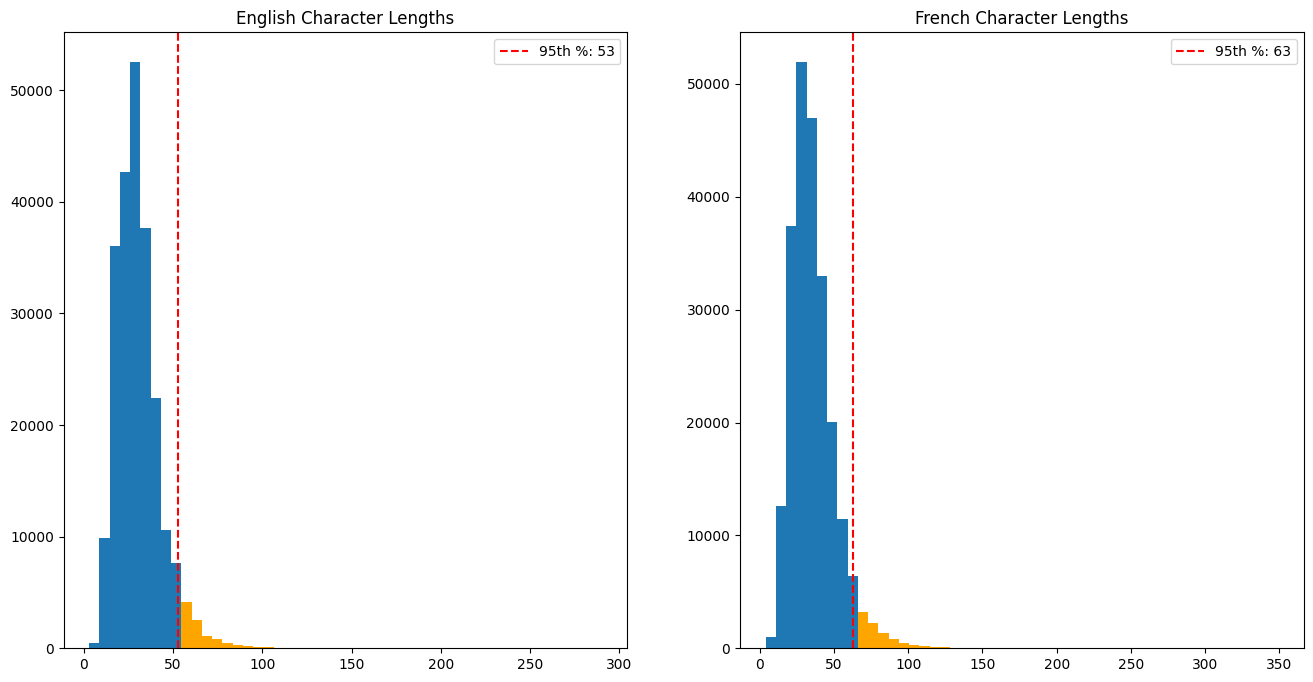

In [13]:
fig,ax = plt.subplots(1,2, figsize = (16,8))

for i, col in enumerate(['English', 'French']):
    lengths = df[col].str.len()
    q95 = lengths.quantile(0.95)
    n,bins, patches = ax[i].hist(lengths, bins = 50, color = 'lightblue')
    for bin_left, patch in zip(bins[:-1], patches):
        if bin_left < q95:
            patch.set_facecolor('#1f77b4')
        else:
            patch.set_facecolor('orange')

    ax[i].axvline(q95, color='red', linestyle='--', label=f'95th %: {q95:.0f}')

    ax[i].set_title(f'{col} Character Lengths')
    ax[i].legend()


**Data Cleaning**

We should filter out the extremely long values to prevent massive padding. I filter out arond the 95th percentile of French texts which also removes outlier texts in the english set.

1) English Characters
* We have soft hyphen and non-breaking space characters, must replace them with "" and " " respectively.
2) French Characters
* We have several other weird characters and odd spaces that I fix

In [14]:
# Weird symbol rows
# df.loc[df['English'].str.contains('[\xa0\xad]',regex=True)]
# df.loc[df['English'].str.contains('₂',regex=True)]

# Clean the text
def clean_data(df):
    clean_df = df.loc[df['French'].str.len() <= 63,: ].copy()

    replacements = {
        '\xa0': ' ',
        '\xad': None,
        '\u2009': ' ',
        '\u200b': '',
        '\u202f': ' ',
    }
    table = str.maketrans(replacements)

    for c in df.columns:
        clean_df[c] = clean_df[c].str.translate(table)

    return clean_df

df = clean_data(df)

**Encode characters**

Special padding tokens, start of sequence and end of sequence tokens to mark key points in translating

In [15]:
english_chars = sorted(set(''.join(df['English'].astype(str))))
french_chars = sorted(list(set(''.join(df['French']))))
special_tokens = ['<PAD>', '<SOS>', '<EOS>']

# Integer to string encodings
fitos = {idx + len(special_tokens):char for idx, char in enumerate(french_chars)}
eitos = {idx + len(special_tokens):char for idx, char in enumerate(english_chars)}

for i, token in enumerate(special_tokens):
    fitos[i] = token
    eitos[i] = token

# String to integer encodings
fstoi ={c:i for i,c in fitos.items()}
estoi ={c:i for i,c in eitos.items()}
estoi

{' ': 3,
 '!': 4,
 '"': 5,
 '$': 6,
 '%': 7,
 '&': 8,
 "'": 9,
 ',': 10,
 '-': 11,
 '.': 12,
 '/': 13,
 '0': 14,
 '1': 15,
 '2': 16,
 '3': 17,
 '4': 18,
 '5': 19,
 '6': 20,
 '7': 21,
 '8': 22,
 '9': 23,
 ':': 24,
 ';': 25,
 '?': 26,
 'A': 27,
 'B': 28,
 'C': 29,
 'D': 30,
 'E': 31,
 'F': 32,
 'G': 33,
 'H': 34,
 'I': 35,
 'J': 36,
 'K': 37,
 'L': 38,
 'M': 39,
 'N': 40,
 'O': 41,
 'P': 42,
 'Q': 43,
 'R': 44,
 'S': 45,
 'T': 46,
 'U': 47,
 'V': 48,
 'W': 49,
 'X': 50,
 'Y': 51,
 'Z': 52,
 'a': 53,
 'b': 54,
 'c': 55,
 'd': 56,
 'e': 57,
 'f': 58,
 'g': 59,
 'h': 60,
 'i': 61,
 'j': 62,
 'k': 63,
 'l': 64,
 'm': 65,
 'n': 66,
 'o': 67,
 'p': 68,
 'q': 69,
 'r': 70,
 's': 71,
 't': 72,
 'u': 73,
 'v': 74,
 'w': 75,
 'x': 76,
 'y': 77,
 'z': 78,
 '°': 79,
 'é': 80,
 'ï': 81,
 'ú': 82,
 '–': 83,
 '‘': 84,
 '’': 85,
 '₂': 86,
 '€': 87,
 '<PAD>': 0,
 '<SOS>': 1,
 '<EOS>': 2}

Define encoding/decoding functions:

1) English input to encoder-> add EOS and pad to max_len_english so all inputs are the same
2) French input to decoder -> shift right and prepend with SOS, pad to max_len_french
3) French target -> add EOS and pad to max_len_french

In [22]:
# +1 because we add a eos/sos char to the longest components
MAX_LEN_ENGLISH = int(df['English'].map(len).max()) + 1
MAX_LEN_FRENCH = int(df['French'].map(len).max()) + 1

def encode_text(text:str, add_eos:bool, add_sos:bool, english = True) -> list[int]:
    """Take a text string and encode to integers + add necessary special characters to it

    Args:
        text (str): text string to be encoded
        add_eos (bool): whether to add <EOS> token
        add_sos (bool): whether to add <SOS> token
        english (bool): whether to pad to MAX_LEN_ENGLISH or MAX_LEN_FRENCH

    Returns:
        list[int]: indices of encoded text
    """

    # Get raw indices from necessary dicts
    indices = [estoi[c] for c in text] if english else [fstoi[c] for c in text]


    # Add the sequence boundaries as necessary
    if add_eos:
        indices.append(estoi['<EOS>'])

    elif add_sos:
        indices.insert(0,estoi['<SOS>'])


    #Pad to necessary length
    num_padding = MAX_LEN_ENGLISH - len(indices) if english else MAX_LEN_FRENCH - len(indices)

    indices.extend([estoi['<PAD>']]* num_padding)

    return indices

def decode_text(indices:list[int],english = False):
    if english:
        return ''.join([eitos[i] for i in indices])
    else:
        return ''.join([fitos[i] for i in indices])


# Try encoding
# english_input = encode_text(df['English'][0],add_eos=True,add_sos=False, english = True)
# french_input = encode_text(df['French'][0],add_eos=False,add_sos=True, english = False)
# french_target = encode_text(df['French'][0],add_eos=True,add_sos=False, english = False)
# decode_text(french_input)
# decode_text(french_target)
# decode_text(english_input, english = True)

In [26]:
df['x_en'] = df['English'].apply(lambda x: encode_text(x,add_eos=True,add_sos=False, english = True))
df['x_fr'] = df['French'].apply(lambda x: encode_text(x,add_eos=False,add_sos=True, english = False))
df['y_fr'] = df['French'].apply(lambda x: encode_text(x,add_eos=True,add_sos=False, english = False))
df.head()

,English,French,x_en,x_fr,y_fr
0,Go.,Va !,"[33, 67, 12, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 51, 56, 3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[51, 56, 3, 4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
1,Go.,Marche.,"[33, 67, 12, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 42, 56, 73, 58, 63, 60, 15, 0, 0, 0, 0, 0,...","[42, 56, 73, 58, 63, 60, 15, 2, 0, 0, 0, 0, 0,..."
2,Go.,En route !,"[33, 67, 12, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 34, 69, 3, 73, 70, 76, 75, 60, 3, 4, 0, 0,...","[34, 69, 3, 73, 70, 76, 75, 60, 3, 4, 2, 0, 0,..."
3,Go.,Bouge !,"[33, 67, 12, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 31, 70, 76, 62, 60, 3, 4, 0, 0, 0, 0, 0, 0...","[31, 70, 76, 62, 60, 3, 4, 2, 0, 0, 0, 0, 0, 0..."
4,Hi.,Salut !,"[34, 61, 12, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 48, 56, 67, 76, 75, 3, 4, 0, 0, 0, 0, 0, 0...","[48, 56, 67, 76, 75, 3, 4, 2, 0, 0, 0, 0, 0, 0..."


#### Train/Val/Test split

Split df

In [34]:
# Shuffle all rows
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# test index boundary, val index boundary 80% and 90% respectively
tidx = int(len(df)*0.8)
vidx = int(len(df)*0.9)

# Create the dfs
train_df = df.iloc[:tidx,:] # 80%
val_df = df.iloc[tidx:vidx,:] # 10%
test_df = df.iloc[vidx:,:] # 10%


Create Tensors

In [38]:
# Tensors
Xtr_en, Xtr_fr, Ytr = torch.tensor(train_df['x_en'].tolist()), torch.tensor(train_df['x_fr'].tolist()), torch.tensor(train_df['y_fr'].tolist())
Xev_en, Xev_fr, Yev = torch.tensor(val_df['x_en'].tolist()), torch.tensor(val_df['x_fr'].tolist()), torch.tensor(val_df['y_fr'].tolist())
Xte_en, Xte_fr, Yte = torch.tensor(test_df['x_en'].tolist()), torch.tensor(test_df['x_fr'].tolist()), torch.tensor(test_df['y_fr'].tolist())

# Check encodings.
# for n in range(5):
#     print(decode_text(Xtr_en[n].tolist(),english=True),decode_text(Xtr_fr[n].tolist()),decode_text(Ytr[n].tolist()),sep='\n',end='\n\n')


Xtr_en.shape, Xev_en.shape, Xte_en.shape

(torch.Size([174910, 86]), torch.Size([21864, 86]), torch.Size([21864, 86]))

## Simple RNN model


#### Description + Implementation


**RNNEncoder**

An RNN that takes in an 87 dim input vector, applies embedding so we have B x 87 x C dimensional tensor per batch where 87 is the time dimension (English characters) and C is the channels/embedding.

Then for each character across the batches, we pass through an RNN layer that takes in the i2h(embedding) of the character + the h2h(hidden) of the previous hidden layer vector. This produces the hidden vector to pass to the next layer.

* i2h -> Simple linear transformation to take the character embedding at a given point in the time dimension and convert it to the hidden layer dimension.
* h2h -> The hidden vector weights matrix, supposed to encapsulate how much meaning to retain as we pass through the characters.

We store the hidden vectors in a list during the for loop and stack them after we pass through all characters to return 1) The output (meaningless in our case) 2) The final hidden vector encapsulating the meaning from the english text

**RNNDecoder**

Takes in the final hidden vectors from the batch (32xHIDDEN_DIM) and, during training, the embeddings of the actual french training examples shifted left by one ([Teacher Forcing](https://machinelearningmastery.com/teacher-forcing-for-recurrent-neural-networks/)). This way, instead of using the model's own predictions as input for the next step, we use the ground-truth french characters.

Again, we do a similar loop as the encoder. Finally, we pass through a linear output layer to arrive at the logits for each character.


**Training**

1) Pass English through encoder, collect final hidden states.
2) Pass final hidden states and encoded teaching example chars to the decoder to obtain the logits for each character position.
3) Cross Entropy Loss and SGD.

During inference, we just pass in a <SEQ> character along with the encoder's final hidden vectors (no teacher forcing).

In [92]:
VOCAB_SIZE_EN = len(english_chars) + len(special_tokens)
VOCAB_SIZE_FR = len(french_chars) + len(special_tokens)
EMBEDDING_DIM = 64
HIDDEN_DIM = 512

class RNNEncoder(torch.nn.Module):
    """RNN Encoder class. Takes in an English input and outputs a hidden state for the decoder."""
    def __init__(self, vocab_size:int, embedding_dim:int, hidden_dim:int,):
        super().__init__()
        self.hidden_dim = hidden_dim
        # Embedding layer for the tokens
        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim)
        self.i2h = torch.nn.Linear(embedding_dim, hidden_dim)
        self.h2h = torch.nn.Linear(hidden_dim, hidden_dim)
        self.act = torch.nn.Tanh()


    def forward(self, Xen:torch.Tensor):
        Xen = self.embedding(Xen)
        B, T, C = Xen.shape
        # Initialise the hidden vector and output vector
        hx = torch.zeros(B, self.hidden_dim)
        outputs = []
        for t in range(T):
            # 32 x 1 x 64 -> 32 x 1 x 256 , + 32 x 256 = hidden vectors across the batch
            pre_act = self.i2h(Xen[:, t, :]) + self.h2h(hx)
            hx = self.act(pre_act)
            outputs.append(hx)

        # Combine the 32 x 256 tensors to have the hidden vectors across time
        rnn_output = torch.stack(outputs, dim = 1)

        # Return the final hidden states, 32x256 , output is irrelevant for this model.
        return hx

class RNNDecoder(torch.nn.Module):
    def __init__(self, vocab_size:int, embedding_dim:int, hidden_dim:int):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim)
        self.i2h = torch.nn.Linear(embedding_dim, hidden_dim)
        self.h2h = torch.nn.Linear(hidden_dim, hidden_dim)
        self.act = torch.nn.Tanh()
        self.out = torch.nn.Linear(hidden_dim, vocab_size)

    def forward(self, Xen:torch.Tensor, hx:torch.Tensor):
        Xen = self.embedding(Xen)
        B, T, C = Xen.shape
        # In the decoder, the outputs store the logits
        # Initially the decoder takes a SOS char plus the meaning encoded in the encoder vectors across the batch
        outputs = []
        for t in range(T):
            pre_act = self.i2h(Xen[:, t, :]) + self.h2h(hx)
            hx = self.act(pre_act)

            logits_example = self.out(hx)

            outputs.append(logits_example)

        # Now we have the logits across the batch 32 x 65 x vocab_size
        logits = torch.stack(outputs, dim = 1)

        return logits, hx


encoder = RNNEncoder(VOCAB_SIZE_EN, EMBEDDING_DIM, HIDDEN_DIM)
decoder = RNNDecoder(VOCAB_SIZE_FR, EMBEDDING_DIM, HIDDEN_DIM)


#### Training Loop

In [93]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Encoder params: {count_parameters(encoder)}")
print(f"Decoder params: {count_parameters(decoder)}")
print(f"Total params:   {count_parameters(encoder) + count_parameters(decoder)}")

Encoder params: 301568
Decoder params: 359406
Total params:   660974


In [94]:
lr=1e-3
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=lr
)

In [100]:
MAX_STEPS = 5000
losses = []
updates = []



for step in range(MAX_STEPS):
    # Get batch tensors
    ix_b = torch.randint(0,Xtr_en.shape[0], size = (64,))
    Xbe,Xbf,Yb = Xtr_en[ix_b], Xtr_fr[ix_b], Ytr[ix_b]
    # Get hidden vectors from encoder
    h = encoder(Xbe)
    # Pass through decoder to get logits
    logitsb, _ = decoder(Xbf,h)
    # Permute for torch API
    logitsb= logitsb.permute(0,2,1)
    loss = F.cross_entropy(logitsb, Yb)

    # Optimisation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # Track stats
    losses.append(loss.item())
    with torch.no_grad():
        updates.append([((lr*p.grad).std()/p.data.std()).log10() for p in list(encoder.parameters()) + list(decoder.parameters())])
    if step % 200 == 0:
        print(f"Step {step}: {loss.item()}")


Step 0: 0.6617076992988586
Step 200: 0.6210300922393799
Step 400: 0.6673844456672668
Step 600: 0.6274991631507874
Step 800: 0.6000312566757202
Step 1000: 0.6130833625793457
Step 1200: 0.6201472878456116
Step 1400: 0.5518002510070801
Step 1600: 0.579165518283844
Step 1800: 0.5854609608650208
Step 2000: 0.5654086470603943
Step 2200: 0.5800552368164062
Step 2400: 0.6501708030700684
Step 2600: 0.5735671520233154
Step 2800: 0.5686350464820862
Step 3000: 0.533606767654419
Step 3200: 0.529075026512146
Step 3400: 0.552092969417572
Step 3600: 0.517287015914917
Step 3800: 0.6052032709121704
Step 4000: 0.5645690560340881
Step 4200: 0.5495554208755493
Step 4400: 0.5310766100883484
Step 4600: 0.5421330332756042
Step 4800: 0.6200745701789856


#### Inference

**Notes**

* Seems to be able to generate French text, does not retain any meaning from the english.

This might be due to the extensive padding at the end of most examples which dilutes the meaning.

Also, maybe the hidden vector is not big enough to capture the meaning of the full sentence (architectural issue)


In [62]:
eng_sentence = Xte_en[2100].view(1,-1)
h = encoder(eng_sentence)

curr_token = torch.tensor([[1]])

decoded_indices = []

max_generation_len = 50

for i in range(max_generation_len):
    logits, h = decoder(curr_token, h)
    probs = F.softmax(logits.squeeze(), dim=0)

    next_token_idx = torch.argmax(probs).item()

    if next_token_idx == 0:
        break

    decoded_indices.append(next_token_idx)

    curr_token = torch.tensor([[next_token_idx]])

print(decode_text(eng_sentence.tolist()[0],english = True))
decode_text(decoded_indices)


I'm glad you dropped by.<EOS><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD>


'Je ne se pas pas de pas de pas de coure de pas de '

#### Diagnostic plots

**Simple Loss**

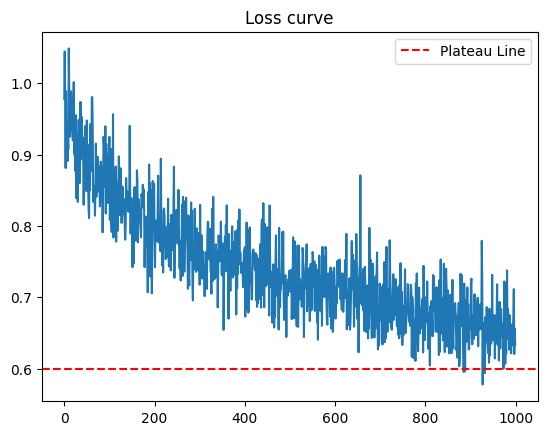

In [99]:
plt.plot(losses)
plt.title("Loss curve")
plt.axhline(y=0.6, color="r", linestyle="--", label="Plateau Line")
plt.legend()
plt.show()

With around 5-10k steps have seen a plateau at around 0.6 with the current architecture.

**Updates across the layers**

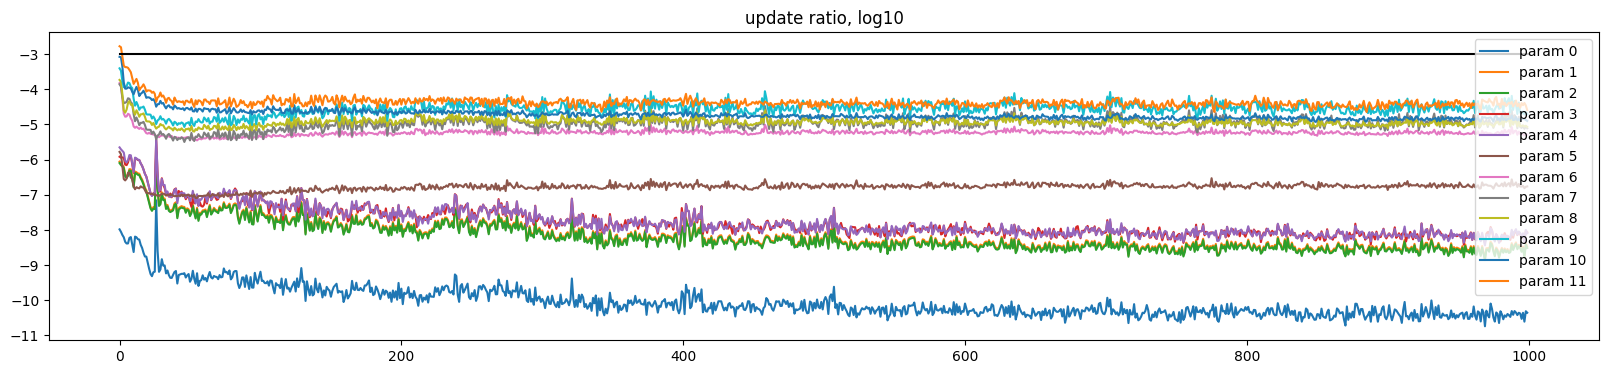

In [91]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(list(encoder.parameters()) + list(decoder.parameters())):

    plt.plot([updates[j][i] for j in range(len(updates))])
    legends.append('param %d' % i)
plt.plot([0, len(updates)], [-3, -3], 'k')
plt.title('update ratio, log10')
plt.legend(legends);

This plot clearly shows that the earlier layers are receiving negligible gradients. This is because each multiplication across the T dimension increases the variances of the hidden vectors. This results in vanishing gradients due to tanh saturation.

Additionally, aside from activations, architecturally, we pass through so many layers that the gradient inevitably becomes very small, even with perfect activations. Hence, we need to swap to LSTM/GRU implementations.

Ilya Sutskever et al. use an LSTM architecture to bridge the time gap between the input and output sequences.

To solve the issue, I will implement a similar LSTM architecture which uses gating mechanisms to preserve gradients over long sequences